# Week 3: Vector Space Semantics (Embeddings & MLPs)

Focused plan: tokenizer → IDs → embeddings → simple model → real‑world usage.


## Tokenizer → IDs → Embedding Inputs
We reuse the Week 2 tokenizer outputs to build vocabulary, IDs, padding, and masks.


In [1]:
from utils import (
    get_imdb_corpus,
    save_json, 
    load_json, 
    train_bpe, 
    create_vocab_mapping, 
    convert_text_to_token_ids,
    save_torch_dataset,
    load_torch_dataset
)

**Note on Saving Artifacts:**

The code to generate and save `bpe_merges.json`, `bpe_vocab.json`, and `vocab_config.json` has been commented out below. This is to prevent accidentally overwriting the files if you have already generated them in Week 2, and to save processing time/disk space. If you are running this from scratch and want to persist these artifacts, feel free to uncomment them!

In [2]:
# texts, labels = get_imdb_corpus()

In [6]:
# bpe_merges = train_bpe(texts, vocab_size=500, min_freq=5, byte_level=True) 
# save_json("datasets/bpe_merges.json", bpe_merges)

**Note on Saving Artifacts:**

The code to generate and save `bpe_merges.json`, `bpe_vocab.json`, and `vocab_config.json` has been commented out below. This is to prevent accidentally overwriting the files if you have already generated them in Week 2, and to save processing time/disk space. If you are running this from scratch and want to persist these artifacts, feel free to uncomment them!

In [6]:
# bpe_vocab = create_vocab_mapping(bpe_merges, pad_token = "[PAD]")
# save_json("datasets/bpe_vocab.json", bpe_vocab)
# vocab_config = {
#     "pad_token": pad_token,
#     "pad_id": bpe_vocab[pad_token],
#     "byte_vocab_size": 256,
#     "max_seq": max_seq,
#     "num_merges": len(bpe_merges),
#     "vocab_size": len(bpe_vocab)
# }
# save_json("models/vocab_config.json", vocab_config)

In [5]:
max_seq = 128
pad_token = "[PAD]"
bpe_merges = load_json("datasets/bpe_merges.json")
bpe_vocab = load_json("datasets/bpe_vocab.json")

**Note on Saving the PyTorch Dataset:**

The code to process and save the PyTorch dataset (`imdb_bpe_dataset.pt`) is commented out below. Saving large tensor files can take up significant disk space and processing time. You can uncomment this cell if you would like to save the dataset to disk for faster loading in future sessions.

In [4]:
# tokenized_features = []
# padding_masks = []
# pad_token = "[PAD]"
# for i, text in enumerate(texts):
#     if i % 1000 == 0 :
#         print(i)
#     tokenized_text, padding_mask = convert_text_to_token_ids(
#         text,
#         bpe_merges,
#         bpe_vocab,
#         max_seq,
#         pad_token
#     )
#     tokenized_features.append(tokenized_text)
#     padding_masks.append(padding_mask)
# save_torch_dataset(tokenized_features, labels, padding_masks, "datasets/imdb_bpe_dataset.pt")

In [6]:
input_ids, labels, padding_masks = load_torch_dataset("datasets/imdb_bpe_dataset.pt")

In [7]:
len(input_ids), len(labels), len(padding_masks)

(50000, 50000, 50000)

## Train a Simple Embedding Model (DAN)

In this section, we will train a **Deep Averaging Network (DAN)** to learn word embeddings specifically tuned for sentiment analysis. A DAN is a simple but highly effective baseline model for text classification.

### Architecture Overview:
The model processes an input sequence of tokens through the following steps:

1. **Embedding Layer**: Converts each token ID in the sequence into a dense, high-dimensional vector. This is where the model learns the semantic meaning of our BPE tokens.
2. **Mean Pooling**: Averages the token embeddings across the sequence length (ignoring `[PAD]` tokens) to create a single, fixed-size vector representing the entire sentence.
3. **Dropout Layer**: Randomly zeroes out some of the pooled features during training to prevent overfitting.
4. **Hidden Linear Layer & ReLU**: A fully connected feed-forward layer followed by a non-linear ReLU activation function, allowing the model to learn complex, non-linear relationships.
5. **Dropout Layer**: Another regularization step.
6. **Linear Output Layer**: Projects the hidden representation down to a single dimension (a scalar logit) for binary classification.
7. **BCEWithLogitsLoss**: The loss function implicitly applies a Sigmoid to output a probability (Positive vs. Negative sentiment) and computes the binary cross-entropy loss.

In [8]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, random_split, DataLoader
from utils import clean_memory, get_device, evaluate_model, train_test_model

In [9]:
class DAN(nn.Module):
    def __init__(self, vocab_size, embedding_size, padding_idx, hidden_dim, n_classes, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_size,padding_idx=padding_idx)
        self.dropout = nn.Dropout(dropout)
        self.hidden = nn.Linear(embedding_size, hidden_dim)
        self.linear = nn.Linear(hidden_dim, n_classes)

    def forward(self, input_ids, mask):
        embedding = self.embedding(input_ids)
        mask = mask.unsqueeze(-1).float()
        masked_embedding = embedding * mask
        mean_pool = masked_embedding.sum(dim=1)/mask.sum(dim=1).clamp(min=1)
        mean_pool = self.dropout(mean_pool)
        hidden = self.hidden(mean_pool) 
        hidden = torch.relu(hidden)
        hidden = self.dropout(hidden)
        return self.linear(hidden)

**Note on Saving the imdb dan model weights:**

The code to train and save the imdb dan model weights (`dan_imdb.pt`) and embedding layer weights (`imdb_embedding_layer.pt`) is commented out below. Saving large files can take up significant disk space and processing time. You can uncomment this cell if you would like to save model weights to disk for faster loading in future sessions.|

In [10]:
vocab_config = load_json("models/vocab_config.json")
pad_id = vocab_config["pad_id"]
vocab_size = vocab_config["vocab_size"]
max_seq = vocab_config["max_seq"]
embedding_size = 384
hidden_dim = embedding_size * 2 
dropout = 0.2
device = get_device()
n_classes = 1
model = DAN(vocab_size, embedding_size, pad_id, hidden_dim, n_classes, dropout).to(device)
criterion = nn.BCEWithLogitsLoss()
patience = 5
num_epochs = 20

In [24]:
# seed = 204
# dataset = TensorDataset(input_ids, padding_masks, labels.float())
# n = len(dataset)
# n_train = int(0.8*n)
# n_val = int(0.1*n)
# n_test = n - n_train - n_val
# g = torch.Generator().manual_seed(seed)
# train_ds, val_ds, test_ds = random_split(dataset, [n_train, n_val, n_test], generator=g)
# train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
# val_loader = DataLoader(val_ds, batch_size=16)
# test_loader = DataLoader(test_ds, batch_size=16)

In [23]:
# clean_memory()

Epoch number 0 train_loss: 0.6284 and val_loss: 0.6048
Epoch number 0 train_accuracy: 0.6376 and val_accuracy: 0.6634
Epoch number 2 train_loss: 0.5924 and val_loss: 0.5921
Epoch number 2 train_accuracy: 0.6757 and val_accuracy: 0.6730
Epoch number 4 train_loss: 0.5824 and val_loss: 0.5909
Epoch number 4 train_accuracy: 0.6858 and val_accuracy: 0.6770
Epoch number 6 train_loss: 0.5707 and val_loss: 0.5943
Epoch number 6 train_accuracy: 0.6976 and val_accuracy: 0.6660
Epoch number 8 train_loss: 0.5576 and val_loss: 0.5966
Epoch number 8 train_accuracy: 0.7058 and val_accuracy: 0.6694
Early stopping at epoch number 9
Train_loss: 0.5514 and val_loss: 0.6012


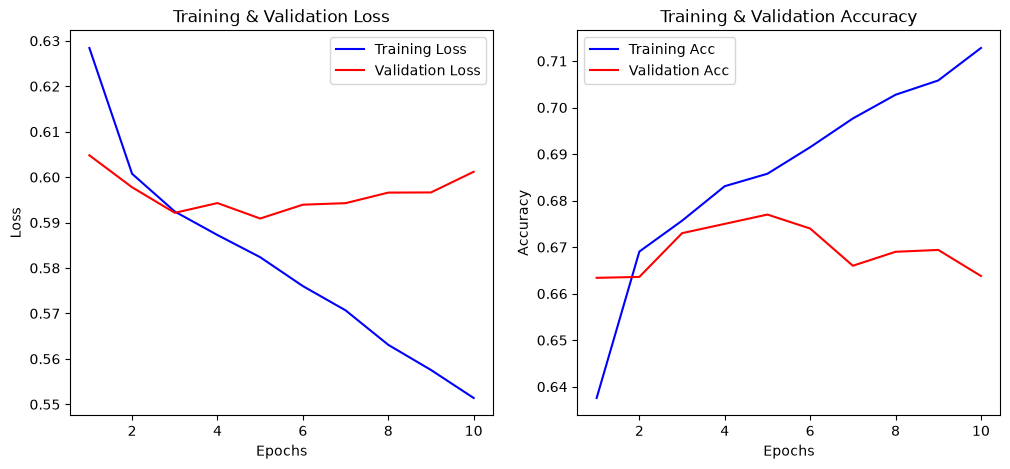

In [26]:
# best_model = train_test_model(
#     device = device,
#     model = model,
#     criterion=criterion,
#     train_loader = train_loader,
#     val_loader = val_loader,
#     patience = patience,
#     num_epochs=num_epochs,
#     lr=1e-3,
#     weight_decay= 1e-5,
#     is_binary=True
# )

In [27]:
# evaluate_model(model=best_model, data_loader=test_loader, criterion=criterion, device=device, is_binary=True)

(0.5744203816587552, 0.6894)

In [28]:
# torch.save(best_model.state_dict(), "models/dan_imdb.pt")
# torch.save(best_model.embedding.state_dict(), "models/imdb_embedding_layer.pt")

## Industry Embeddings comparison (Brief Overview)
- **GloVe (Global Vectors for Word Representation):** Unsupervised word embeddings learned from global word-word co-occurrence statistics across a massive corpus. It works by constructing a massive co-occurrence matrix (counting how often words appear near each other within a context window) and then applying a form of matrix factorization to reduce this massive sparse matrix into a lower-dimensional, dense vector space. While it powerfully captures general semantic relationships (like vector analogies), it lacks positional or dynamic contextual information. This means a word like "bank" will always map to the exact same static vector, regardless of whether it refers to a river bank or a financial institution.
- **SBERT (Sentence-BERT) & the SentenceTransformers Library:** SBERT is a modification of the pre-trained BERT network that uses siamese and triplet network structures to derive semantically meaningful sentence embeddings. Unlike standard BERT, which requires feeding two sentences simultaneously into the network to compute a similarity score (which is computationally expensive), SBERT allows you to compute sentence embeddings independently and then rapidly compare them using cosine similarity. In this notebook, we use the `sentence-transformers` library from Hugging Face. This library is built on top of `transformers` and is specifically engineered to make loading these optimized models and computing dense vector representations incredibly simple and efficient (often in just two lines of code!). It uses an encoder-only Transformer architecture with bidirectional self-attention to capture deep context, followed by a mean pooling layer across all output tokens to generate a single, dense vector representing the entire sentence.
- **Trained DAN Embedding:** Learns embeddings from the IMDB task. It does not model word order and uses mean pooling over token embeddings, but it still captures useful task-specific semantics.

### Comparison:
The trained DAN embeddings performed strongly on movie-related similarity, which makes sense given they were trained on IMDB. GloVe performed worse because it is context-free, and many different sentences can end up with similar averaged vectors. SBERT was strongest overall but the DAN model held its own in domain-specific cases.

### To load GloVe model:
1. cd models
2. curl -L -O https://nlp.stanford.edu/data/glove.6B.zip
3. unzip glove.6B.zip


In [11]:
from sentence_transformers import SentenceTransformer
from utils import (
    bpe_batch_encode, 
    load_glove_txt, 
    get_glove_sent_embed, 
    get_sbert_embed, 
    get_dan_sent_embed, 
    plot_heatmap, 
    cos_sim_matrix
)

In [12]:
dan_model = DAN(vocab_size, embedding_size, pad_id, hidden_dim, 1,dropout)
state = torch.load("models/dan_imdb.pt", map_location="cpu")
dan_model.load_state_dict(state)
dan_embedding = dan_model.embedding
dan_embedding.weight.requires_grad_(False)

Parameter containing:
tensor([[-9.5405e-33,  9.6923e-33,  1.0410e-32,  ..., -9.8666e-33,
          9.7548e-33,  9.7743e-33],
        [-1.0357e-32,  9.8366e-33, -1.0154e-32,  ...,  9.6586e-33,
          1.0140e-32,  1.0548e-32],
        [ 9.7172e-33, -9.9502e-33, -1.0672e-32,  ...,  9.7970e-33,
          1.0438e-32,  1.0340e-32],
        ...,
        [-7.0091e-02, -1.2301e-01, -2.1947e-01,  ..., -3.3290e-02,
          1.5382e-01, -2.9366e-02],
        [ 1.3067e-01,  9.9657e-02,  1.2699e-02,  ...,  1.0270e-01,
         -8.9688e-02, -1.2874e-01],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00]])

In [13]:
sentences = [
    "I loved the movie, it was fantastic.",
    "The film was terrible and boring.",
    "An airplane took off from the runway.",
    "I really enjoyed the plot and the acting.",
    "The dog chased the ball in the park."
]

In [14]:
# DAN sentence embeddings
input_ids, padding_mask = bpe_batch_encode(sentences, bpe_merges, bpe_vocab, max_seq, pad_token)
dan_sent_emb = get_dan_sent_embed(dan_embedding, input_ids, padding_mask)
# GloVe sentence embeddings
glove = load_glove_txt(path="models/glove.6B.300d.txt", dim=300)
glove_sent_emb = torch.stack([get_glove_sent_embed(s, glove, 300) for s in sentences])
# SBERT sentence embeddings
sbert = SentenceTransformer("all-MiniLM-L6-v2")
sbert_sent_emb = get_sbert_embed(sbert, sentences)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

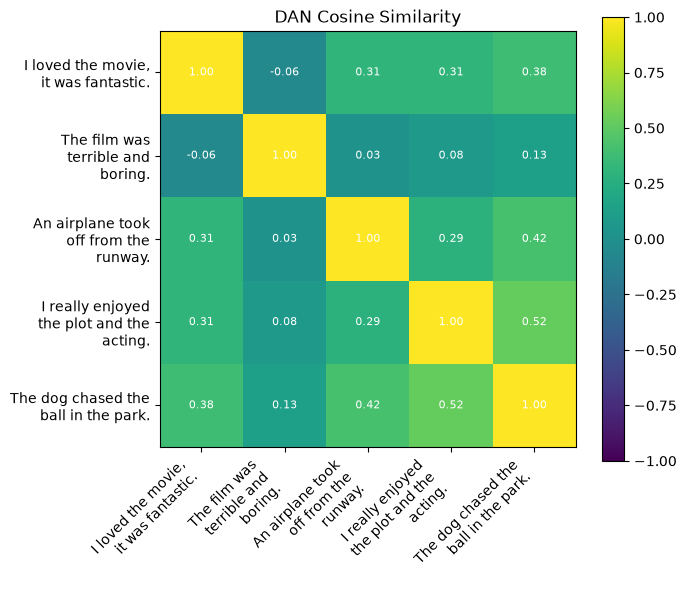

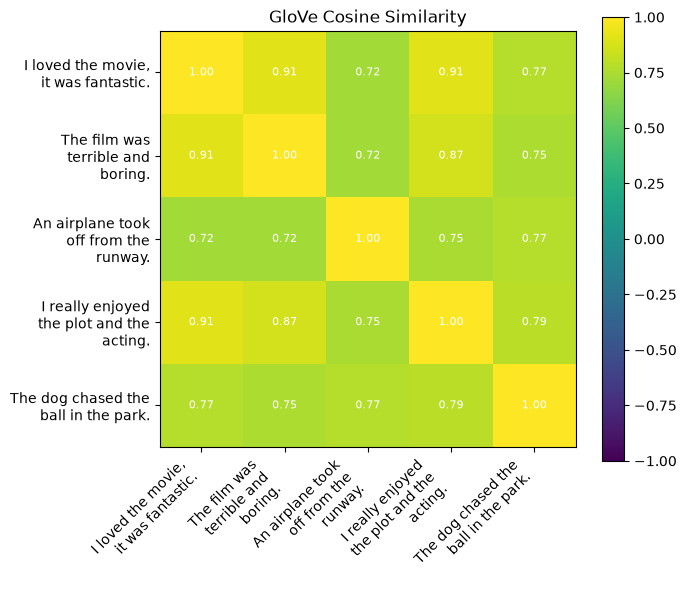

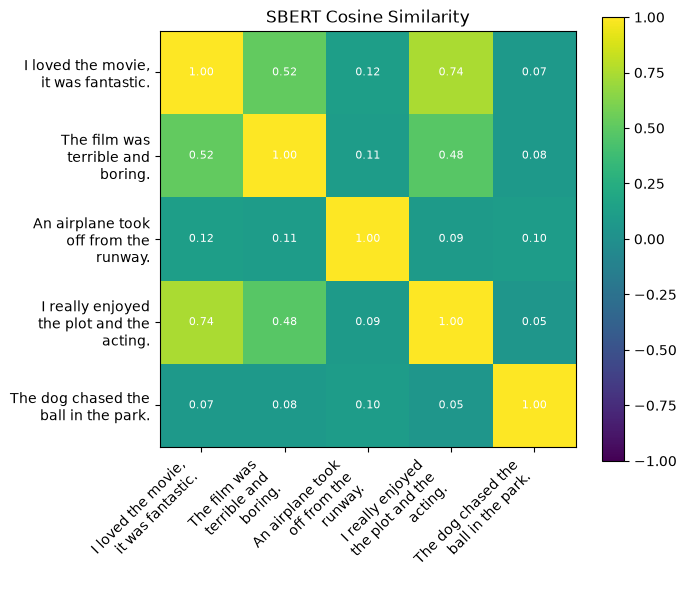

In [15]:
# use the actual sentences for both axes
plot_heatmap(cos_sim_matrix(dan_sent_emb), "DAN Cosine Similarity", sentences)
plot_heatmap(cos_sim_matrix(glove_sent_emb), "GloVe Cosine Similarity", sentences)
plot_heatmap(cos_sim_matrix(sbert_sent_emb), "SBERT Cosine Similarity", sentences) 

## Real-World Embedding Uses: RAG (Retrieval-Augmented Generation)
While embeddings can be used for clustering or classification, one of the most powerful real-world applications today is **RAG (Retrieval-Augmented Generation)**. In a RAG pipeline, embeddings are used to inject factual, relevant context into a large language model (LLM). The process typically follows these three steps:

1. **Similarity Search**: The user query is converted into an embedding vector. We then compute the cosine similarity between this query embedding vector and a large database of pre-computed document embedding vectors.
2. **Pick Nearest Neighbors**: The system ranks the documents based on their similarity scores and selects the top-$K$ most mathematically similar embedding vectors(the "nearest neighbors" in the vector space).
3. **Grab Relevant Context**: The original raw text corresponding to those top-$K$ nearest neighbors is retrieved and injected into an LLM prompt as factual context. This allows the LLM to generate an accurate, hallucination-free response based strictly on the retrieved documents.


### Measuring Similarity: Cosine Similarity vs. Other Methods
In the heatmaps above and the retrieval demo below, we use **Cosine Similarity** to determine how close two sentence embeddings are. But what exactly is it, and how does it compare to other distance metrics?

- **Cosine Similarity:** Measures the cosine of the angle between two vectors in a multi-dimensional space. It ranges from -1 (completely opposite) to 1 (exactly the same direction). Because it only calculates the *angle* and ignores the *magnitude* (length) of the vectors, it is extremely robust for NLP. Two sentences can have different lengths and token counts, but if they point in the same semantic direction, their cosine similarity will be high.
- **Euclidean Distance (L2 Distance):** Measures the straight-line distance between two points in vector space. Unlike Cosine Similarity, Euclidean Distance is highly sensitive to the magnitude of the vectors. If two vectors point in the exact same semantic direction but one is much longer, their Euclidean distance will be large, making it less ideal for unnormalized text embeddings.
- **Jaccard Similarity:** A classic set-based metric that measures the intersection over the union of two sets of tokens (words). It is great for basic keyword matching (lexical search), but it completely fails at semantic search. For example, *"The puppy played"* and *"A little dog had fun"* have a Jaccard Similarity of 0 (no shared words), even though their semantic embeddings would have a very high Cosine Similarity.
- **Dot Product:** Similar to Cosine Similarity, but without normalizing the vector lengths. If an embedding model is explicitly trained to output normalized vectors (where magnitude = 1), Dot Product and Cosine Similarity are mathematically identical, and Dot Product is often preferred in production systems because it is computationally faster.


### RAG‑Style Semantic Search (Retrieval Demo)
We build embeddings for a small out‑of‑domain corpus and retrieve the most relevant snippets for a query.
You can swap the embedder (SBERT, DAN, or GloVe).We cosine similiarty use similarity search result for the most relevant context. 


In [16]:
from utils import semantic_search,print_embedding_result

In [17]:
imdb_like_docs = [
    "The movie was a thrilling ride from start to finish.",
    "I loved the performances, but the plot felt a little predictable.",
    "The film was painfully slow and far too long.",
    "An emotional story with beautiful cinematography and a powerful ending.",
    "The acting was wooden, and the dialogue sounded unnatural.",
    "I was completely drawn into the world of the movie.",
    "The pacing was uneven, but the soundtrack was excellent.",
    "This was one of the funniest comedies I have seen in years.",
    "The ending was disappointing after such a strong opening.",
    "A visually stunning film with very little substance underneath.",
    "The lead actor carried the entire movie with a fantastic performance.",
    "I found the story confusing and hard to follow.",
    "The chemistry between the characters made the romance believable.",
    "It was a dull and forgettable sequel that added nothing new.",
    "The suspense kept me guessing until the final scene.",
    "I expected much more from such a talented cast.",
    "The script was sharp, clever, and full of memorable lines.",
    "Some scenes were powerful, but overall the movie felt messy.",
    "The direction was bold and creative, even if the story was strange.",
    "I would happily watch this film again.",
    "The jokes did not land, and the humor felt forced.",
    "A moving and heartfelt drama that stayed with me afterward.",
    "The special effects were impressive, but the characters were flat.",
    "This film was overrated and not worth the hype.",
    "A charming, well-acted movie that delivered exactly what I hoped for."
]


non_imdb_like_docs = [
    "Reset your router by holding the reset button for 10 seconds until the lights blink.",
    "Two-factor authentication adds a second step to verify your identity.",
    "A strong password uses a mix of letters, numbers, and symbols.",
    "Clear your browser cache to fix loading issues on some websites.",
    "Update your device regularly to install important security patches.",
    "A layover is the waiting time between connecting flights.",
    "Arrive at the airport two hours early for most domestic flights.",
    "Travel insurance can cover trip delays, cancellations, and medical emergencies.",
    "Jet lag can be reduced by gradually adjusting your sleep schedule before travel.",
    "Pack liquids in small containers when traveling with carry-on luggage.",
    "Dehydration symptoms include dry mouth, dizziness, and fatigue.",
    "A balanced meal usually includes protein, fiber, and healthy fats.",
    "Walking every day can support heart health and improve mood.",
    "Stretching regularly may improve flexibility and reduce injury risk.",
    "A fever is often a sign that the body is fighting an infection.",
    "A budget tracks income, expenses, and savings goals over time.",
    "An emergency fund helps cover unexpected costs like repairs or medical bills.",
    "Index funds spread investment risk across many companies.",
    "Compound interest helps savings grow faster over longer periods.",
    "Credit scores are influenced by payment history and credit utilization.",
    "A refund policy explains when customers can return products for money back.",
    "Shipping delays are more common during holidays and peak seasons.",
    "Data backups help protect against accidental loss and file corruption.",
    "Encryption protects sensitive information both in storage and in transit.",
    "APIs allow different software systems to communicate with each other."
]

docs = imdb_like_docs + non_imdb_like_docs

### Check for performance for both imdb and non imdb_queries

In [18]:
imdb_query = "I want a movie with strong acting and an emotional story."
non_imdb_query = "How can I make my online account more secure?"
all_queries = [imdb_query, non_imdb_query]
# ---- DAN embeddings ----
doc_ids, doc_mask = bpe_batch_encode(docs, bpe_merges, bpe_vocab, max_seq, pad_token)
dan_doc_embs = get_dan_sent_embed(dan_embedding, doc_ids, doc_mask)
dan_query_fn = lambda q: get_dan_sent_embed(dan_embedding, *bpe_batch_encode([q], bpe_merges, bpe_vocab, max_seq, pad_token))[0]

# ---- GloVe embeddings ----
glove_doc_embs = torch.stack([get_glove_sent_embed(s, glove, 300) for s in docs])
glove_query_fn = lambda q: get_glove_sent_embed(q, glove, 300)

# ---- SBERT embeddings ----
sbert_doc_embs = sbert.encode(docs, convert_to_tensor=True)
sbert_query_fn = lambda q: sbert.encode([q], convert_to_tensor=True)[0]

model_mappings = {
    "DAN":{
        "doc_embs": dan_doc_embs,
        "query_fn": dan_query_fn
    },
    "GloVe": {
        "doc_embs": glove_doc_embs,
        "query_fn": glove_query_fn,
    },
    "SBERT": {
        "doc_embs": sbert_doc_embs,
        "query_fn": sbert_query_fn
    }
    
}

for model_type, emb_dict in model_mappings.items():
    for query in all_queries:
        print(f"\nquery questions: {query}")
        print_embedding_result(query, docs, emb_dict["doc_embs"], emb_dict["query_fn"], 2, model_type)
        print("---"*36)


query questions: I want a movie with strong acting and an emotional story.

 DAN semantic search:
0.402 | An emotional story with beautiful cinematography and a powerful ending.
0.381 | The direction was bold and creative, even if the story was strange.
------------------------------------------------------------------------------------------------------------

query questions: How can I make my online account more secure?

 DAN semantic search:
0.449 | A refund policy explains when customers can return products for money back.
0.345 | An emergency fund helps cover unexpected costs like repairs or medical bills.
------------------------------------------------------------------------------------------------------------

query questions: I want a movie with strong acting and an emotional story.

 GloVe semantic search:
0.921 | A moving and heartfelt drama that stayed with me afterward.
0.918 | An emotional story with beautiful cinematography and a powerful ending.
---------------------

## Summary

* SBERT did best because it is built for sentence-level semantic similarity across general domains.
* GloVe did well on the IMDB-like query but performed poorly on the non-IMDB query because averaging static word vectors loses context and often flattens sentence meaning.
* DAN did okay on IMDB-like text because it learned from movie-review sentiment data, so it has useful domain-specific signal there.
* DAN did poorly on non-IMDB text because it was not trained to generalize broadly across unrelated domains like security, travel, or finance.

This also shows that embedding model choice can strongly affect RAG quality, because retrieval depends on how well the embedding space captures the meaning of the query and documents. Better embeddings lead to more relevant retrieved context, while weaker or domain-mismatched embeddings can return irrelevant chunks and hurt the final LLM response.

Tokenization turns raw text into discrete units, ID mapping makes them model-ready, and embeddings translate those IDs into dense vectors.
Mean pooling and simple classifiers show how token-level representations become sentence-level features.
This setup does not model attention or positional relationships, which are added later in Transformer-based LLMs.
These steps mirror the front end of modern LLM pipelines: tokenize → ids → embeddings → downstream reasoning or generation.